In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

from tqdm import tqdm
from skimage.transform import resize
from skimage.metrics import peak_signal_noise_ratio
from skimage.metrics import structural_similarity
from skimage.metrics import mean_squared_error

print("Bicubic Baseline Experiment Started")

Bicubic Baseline Experiment Started


In [2]:
GT_PATH = "../data/train/GT"
NOISY_PATH = "../data/train/NoisyLR"


files = sorted(os.listdir(GT_PATH))

print("Total images:", len(files))

Total images: 3200


In [3]:
OUTPUT_PATH="../results/bicubic"

os.makedirs(
    OUTPUT_PATH,
    exist_ok=True
)

print("Output folder created")

Output folder created


In [4]:
psnr_scores=[]
ssim_scores=[]
mae_scores=[]


for f in tqdm(files):

    gt=np.load(
        os.path.join(GT_PATH,f)
    )


    noisy=np.load(
        os.path.join(NOISY_PATH,f)
    )


    # Bicubic upsampling
    restored = resize(
        noisy,
        gt.shape,
        order=3,
        anti_aliasing=True
    )


    # Metrics

    psnr=peak_signal_noise_ratio(
        gt,
        restored,
        data_range=1
    )


    ssim=structural_similarity(
        gt,
        restored,
        data_range=1
    )


    mae=mean_squared_error(
        gt,
        restored
    )


    psnr_scores.append(psnr)
    ssim_scores.append(ssim)
    mae_scores.append(mae)


    # save output

    np.save(
        os.path.join(
            OUTPUT_PATH,
            f
        ),
        restored
    )


print("Completed")

100%|██████████| 3200/3200 [00:41<00:00, 78.00it/s]

Completed


In [5]:
print("Average PSNR:",
      np.mean(psnr_scores))


print("Average SSIM:",
      np.mean(ssim_scores))


print("Average MSE:",
      np.mean(mae_scores))

Average PSNR: 22.379248691749204
Average SSIM: 0.5240064320651469
Average MSE: 0.007779261868963858


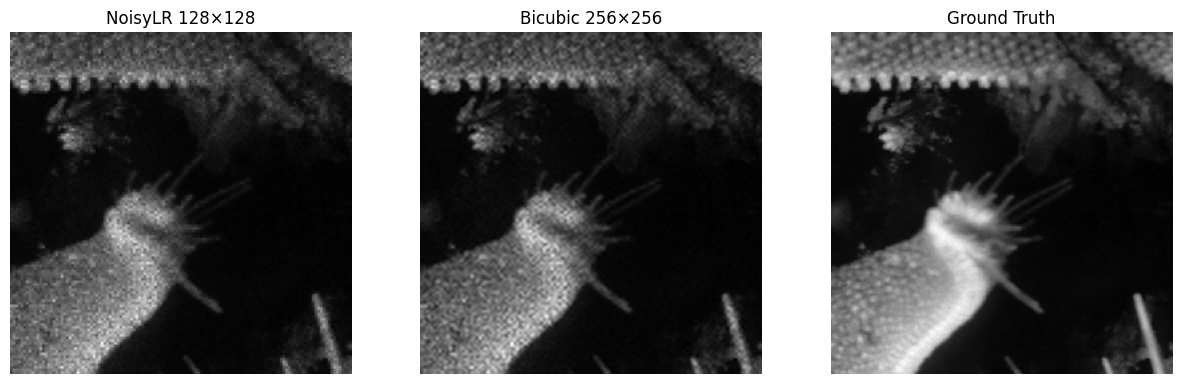

In [6]:
idx="000000.npy"


gt=np.load(
    os.path.join(GT_PATH,idx)
)

noisy=np.load(
    os.path.join(NOISY_PATH,idx)
)


bicubic=np.load(
    os.path.join(
        OUTPUT_PATH,
        idx
    )
)


plt.figure(figsize=(15,5))


plt.subplot(1,3,1)
plt.imshow(noisy,cmap="gray")
plt.title("NoisyLR 128×128")
plt.axis("off")


plt.subplot(1,3,2)
plt.imshow(bicubic,cmap="gray")
plt.title("Bicubic 256×256")
plt.axis("off")


plt.subplot(1,3,3)
plt.imshow(gt,cmap="gray")
plt.title("Ground Truth")
plt.axis("off")


plt.show()

In [8]:
import os

RESULT_PATH = "../results/bicubic"

os.makedirs(RESULT_PATH, exist_ok=True)
os.makedirs(
    os.path.join(RESULT_PATH, "images"),
    exist_ok=True
)

print("Folders created")

Folders created


In [9]:
metrics_file = os.path.join(
    RESULT_PATH,
    "metrics.txt"
)

with open(metrics_file, "w") as f:
    f.write("Experiment: Bicubic Interpolation Baseline\n")
    f.write("-----------------------------------------\n\n")
    
    f.write("Dataset: KLA Semiconductor Image Restoration\n")
    f.write("Training samples: 3200\n\n")
    
    f.write("Input:\n")
    f.write("NoisyLR 128x128\n\n")
    
    f.write("Output:\n")
    f.write("Bicubic restored 256x256\n\n")
    
    f.write("Performance Metrics\n")
    f.write("-------------------\n")
    f.write(f"Average PSNR: {np.mean(psnr_scores):.6f} dB\n")
    f.write(f"Average SSIM: {np.mean(ssim_scores):.6f}\n")
    f.write(f"Average MSE: {np.mean(mae_scores):.10f}\n")

print("Metrics saved")

Metrics saved


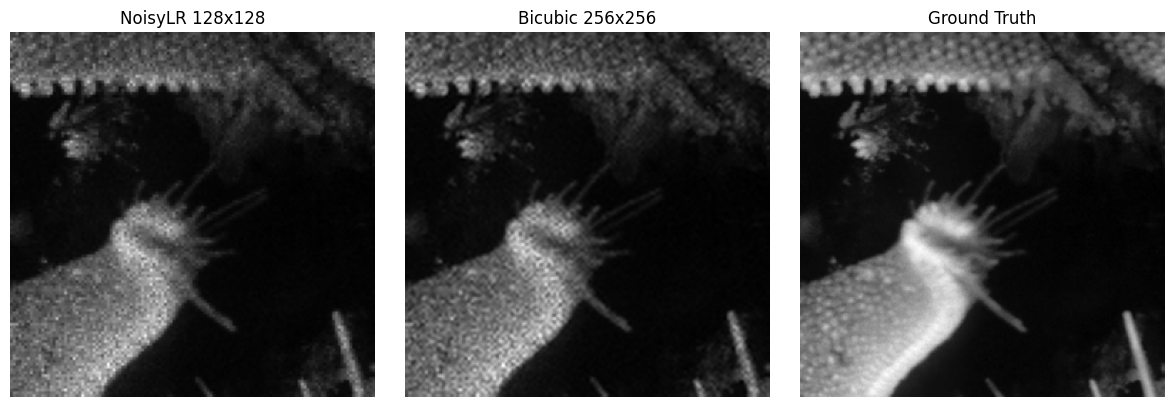

Comparison image saved


In [10]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(noisy,cmap="gray")
plt.title("NoisyLR 128x128")
plt.axis("off")


plt.subplot(1,3,2)
plt.imshow(bicubic,cmap="gray")
plt.title("Bicubic 256x256")
plt.axis("off")


plt.subplot(1,3,3)
plt.imshow(gt,cmap="gray")
plt.title("Ground Truth")
plt.axis("off")


plt.tight_layout()

plt.savefig(
    "../results/bicubic/comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Comparison image saved")

In [14]:
import os
import numpy as np
import matplotlib.pyplot as plt

# folder containing bicubic npy outputs
NPY_PATH = "../results/bicubic"

# folder to save png images
PNG_PATH = "../results/bicubic/images"

os.makedirs(PNG_PATH, exist_ok=True)

files = sorted([
    f for f in os.listdir(NPY_PATH)
    if f.endswith(".npy")
])

print("Total files:", len(files))


for f in files:

    img = np.load(
        os.path.join(
            NPY_PATH,
            f
        )
    )

    save_name = f.replace(".npy",".png")

    plt.imsave(
        os.path.join(
            PNG_PATH,
            save_name
        ),
        img,
        cmap="gray"
    )


print("All bicubic restored PNG images saved")

Total files: 3200
All bicubic restored PNG images saved


In [15]:
import shutil
import os

example_path="../results/bicubic/examples"

os.makedirs(example_path,exist_ok=True)

samples=[
    "000000.png",
    "000100.png",
    "001000.png",
    "002000.png",
    "003000.png"
]

for s in samples:
    shutil.copy(
        "../results/bicubic/images/"+s,
        example_path
    )

print("Example images copied")

Example images copied
